# Word Embeddings

Welcome to this complete, self-contained solution notebook on **text preprocessing** and **word embeddings**.

In this assignment, we will work with book metadata such as titles, authors, descriptions, genres, and places. Our goal is to transform this raw text into meaningful numerical representations that can capture relationships between words.

---

## 🎯 Assignment Goal

The main objective is to train, test, visualize, and compare different word embedding models.

We will implement and explore three approaches:

### 1. Word2Vec from Scratch
We will build a simple **Skip-Gram Word2Vec model** using negative sampling.  
This helps us understand how word embeddings are learned internally.

### 2. FastText with Gensim
We will train a FastText model using the `gensim` library.  
FastText improves on Word2Vec by learning from subword information, which helps with rare or unseen words.

### 3. FastText with the Native `fasttext` Package
We will also use the official `fasttext` package to train embeddings and compare its behavior with the Gensim implementation.

---

## 🧠 What You Will Learn

By the end of this notebook, you will be able to:

- clean and normalize raw book metadata,
- convert text into a training corpus,
- build a vocabulary from tokenized text,
- generate Skip-Gram training pairs,
- train word embeddings from scratch,
- train FastText embeddings using two different libraries,
- test semantic relationships using simple analogy examples,
- visualize learned word vectors in two dimensions,
- compare the strengths and limitations of Word2Vec and FastText.

---

## 🧩 Final Outcome

At the end of the notebook, we will have multiple trained embedding models and a clearer understanding of how different embedding techniques represent words, authors, genres, and places in a shared vector space.

## 1. Environment Setup

The notebook contains all assignment code directly in notebook cells.

Some libraries may already be installed in your environment. If a package is missing, run the optional installation cell below.

In [1]:
# Optional installation cell.
# Change RUN_INSTALLS to True only if your environment is missing packages.

RUN_INSTALLS = True

if RUN_INSTALLS:
    import sys
    import subprocess

    packages = [
        "pandas",
        "numpy",
        "matplotlib",
        "nltk",
        "gensim",
        "tqdm",
        "fasttext",
    ]

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        *packages,
    ])

    print("Packages installed.")
else:
    print("Skipping installation. Set RUN_INSTALLS = True if packages are missing.")

CalledProcessError: Command '['c:\\Users\\francois\\AppData\\Local\\Programs\\Python\\Python311\\python.exe', '-m', 'pip', 'install', '-q', 'pandas', 'numpy', 'matplotlib', 'nltk', 'gensim', 'tqdm', 'fasttext']' returned non-zero exit status 1.

In [3]:
import math
import random
import re
import tempfile
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Some libraries still have non-deterministic behavior when using multiple workers,
# but fixing these seeds makes the scratch model and sampling steps more stable.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable, **kwargs):
        return iterable

print("Core libraries loaded.")

Core libraries loaded.


## 2. Dataset

For a fully standalone run, this notebook includes a small built-in book metadata dataset.

The dataset has the same kind of columns expected in this assignment:

- `title`
- `author`
- `description`
- `genres`
- `places`

A larger CSV can also be used by setting `USE_EXTERNAL_CSV = True`.

In [4]:
CSV_PATH = Path("top_3000_rated_books.csv")


if CSV_PATH.exists():
    books_df = pd.read_csv(CSV_PATH)
    data_source = f"Loaded external dataset from {CSV_PATH}"

print(data_source)
print(f"Number of rows: {len(books_df)}")
books_df.head()

Loaded external dataset from top_3000_rated_books.csv
Number of rows: 3000


,Unnamed: 0,bookId,title,author,series,description,genres,awards,characters,places,...,publish_date,num_pages,num_ratings,num_reviews,avg_rating,rated_1,rated_2,rated_3,rated_4,rated_5
0,4249,4255,Harry Potter and the Philosopher's Stone,J.K. Rowling,Harry Potter #1,When a letter arrives for unhappy but ordinary...,"Art,Biography,Business,Children's,Christian,Cl...",Mythopoeic Fantasy Award for Children's Litera...,"Draco Malfoy,Ron Weasley,Petunia Dursley,Verno...","London, England,Hogwarts School of Witchcraft ...",...,October 4th 2004,223.0,7437005.0,117859.0,4.48,126396.0,147247.0,627970.0,1694668.0,4840724.0
1,2,3,Harry Potter and the Sorcerer's Stone,"J.K. Rowling,Mary GrandPré",Harry Potter #1,Harry Potter's life is miserable. His parents ...,"Art,Biography,Business,Children's,Christian,Cl...",Mythopoeic Fantasy Award for Children's Litera...,"Draco Malfoy,Ron Weasley,Petunia Dursley,Verno...","London, England,Hogwarts School of Witchcraft ...",...,November 1st 2003,309.0,7434783.0,117823.0,4.48,126344.0,147184.0,627803.0,1694206.0,4839246.0
2,12110,12024,Twilight,Stephenie Meyer,The Twilight Saga #1,"About three things I was absolutely positive.,...","Art,Biography,Business,Children's,Christian,Cl...","Georgia Peach Book Award 2007,Buxtehuder Bulle...","Edward Cullen,Jacob Black,Laurent,Renee,Bella ...","Forks, Washington,Phoenix, Arizona,Washington ...",...,2005,544.0,5173079.0,106718.0,3.61,562807.0,560978.0,1052619.0,1164865.0,1831810.0
3,2656,2661,To Kill a Mockingbird,Harper Lee,To Kill a Mockingbird,Lawyer Atticus Finch defends the real mockingb...,"Art,Biography,Business,Children's,Christian,Cl...","Pulitzer Prize for Fiction 1961,Audie Award fo...","Scout Finch,Atticus Finch,Jem Finch,Arthur Rad...","Maycomb, Alabama,Alabama",...,October 17th 2006,323.0,4712812.0,94358.0,4.28,85019.0,156544.0,598802.0,1395089.0,2477358.0
4,2655,2660,To Kill a Mockingbird,Harper Lee,To Kill a Mockingbird,Harper Lee's classic novel of a lawyer in the ...,"Art,Biography,Business,Children's,Christian,Cl...","Pulitzer Prize for Fiction 1961,Audie Award fo...","Scout Finch,Atticus Finch,Jem Finch,Arthur Rad...","Maycomb, Alabama,Alabama",...,January 1st 1962,284.0,4712812.0,94358.0,4.28,85019.0,156544.0,598802.0,1395089.0,2477358.0


## 3. 🧹 Text Preprocessing

Before we can train word embedding models, we need to prepare the raw book metadata.

Book metadata usually contains a mixture of useful words, punctuation, repeated terms, numbers, and common words such as *the*, *and*, or *is*. These extra elements can make training less effective, so we first convert the raw text into a cleaner and more consistent format.
is Step

The goal of this section is to transform each book record into a clean list of meaningful tokens.

For example, a raw sentence like:

> A fantasy story about a young wizard, friendship, school, magic, and courage.

may become something like:

```text
["fantasy", "story", "young", "wizard", "friendship", "school", "magic", "courage"]

In [ ]:
STOPWORDS = {
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves",
    "you", "your", "yours", "yourself", "yourselves",
    "he", "him", "his", "himself", "she", "her", "hers", "herself",
    "it", "its", "itself", "they", "them", "their", "theirs", "themselves",
    "what", "which", "who", "whom", "this", "that", "these", "those",
    "am", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "having", "do", "does", "did", "doing",
    "a", "an", "the", "and", "but", "if", "or", "because", "as",
    "until", "while", "of", "at", "by", "for", "with", "about",
    "against", "between", "into", "through", "during", "before",
    "after", "above", "below", "to", "from", "up", "down", "in",
    "out", "on", "off", "over", "under", "again", "further",
    "then", "once", "here", "there", "when", "where", "why", "how",
    "all", "any", "both", "each", "few", "more", "most", "other",
    "some", "such", "no", "nor", "not", "only", "own", "same",
    "so", "than", "too", "very", "s", "t", "can", "will", "just",
    "don", "should", "now",
}

DOMAIN_STOPWORDS = {
    "title", "titl",
    "author",
    "description", "descript",
    "genre", "genres", "genr",
    "place", "places",
    "goodreads", "goodread",
    "page", "pages",
    "book", "books",
    "edition", "editions",
    "isbn",
    "cover",
    "paperback",
    "hardcover",
    "kindle",
    "ebook",
}

ALL_STOPWORDS = STOPWORDS | DOMAIN_STOPWORDS

USE_STEMMING = False
stemmer = None
USE_LEMMATIZATION = True

lemmatizer = None
WORDNET_AVAILABLE = False

if USE_LEMMATIZATION:
    try:
        import nltk
        from nltk.stem import WordNetLemmatizer
        nltk.download("wordnet", quiet=True)
        nltk.download("omw-1.4", quiet=True)
        lemmatizer = WordNetLemmatizer()
        WORDNET_AVAILABLE = True
    except Exception:
        lemmatizer = None
        WORDNET_AVAILABLE = False
        print("WordNet is not available. Continuing without lemmatization.")


def normalize_token(token):
   
    token = token.lower().strip()

    if USE_LEMMATIZATION and lemmatizer is not None:
        token = lemmatizer.lemmatize(token)

    return token


print(f"Number of general stopwords: {len(STOPWORDS)}")
print(f"Number of domain stopwords: {len(DOMAIN_STOPWORDS)}")
print(f"Total stopwords used: {len(ALL_STOPWORDS)}")
print(f"Stemming enabled: {USE_STEMMING}")
print(f"Lemmatization enabled: {USE_LEMMATIZATION and WORDNET_AVAILABLE}")


Number of general stopwords: 127
Number of domain stopwords: 24
Total stopwords used: 151
Stemming enabled: False
Lemmatization enabled: True


In [6]:
class DataPreprocessor:
    """
    Converts book metadata into a clean tokenized corpus.
    """

    def __init__(self, stopwords=None):
        self.stopwords = stopwords if stopwords is not None else set()

    def normalize_token(self, token):
        if lemmatizer is not None:
            try:
                token = lemmatizer.lemmatize(token)
            except Exception:
                pass

        if stemmer is not None:
            try:
                token = stemmer.stem(token)
            except Exception:
                pass

        return token

    def clean_text(self, text):
        if pd.isna(text):
            return ""

        text = str(text).lower()
        text = re.sub(r"[^a-z\s]", " ", text)
        words = text.split()
        cleaned_words = []

        for word in words:
            if word in self.stopwords:
                continue
            if len(word) <= 2:
                continue
            normalized = self.normalize_token(word)
            if normalized and normalized not in self.stopwords and len(normalized) > 2:
                cleaned_words.append(normalized)

        return " ".join(cleaned_words)

    def build_corpus(self, df):
        required_columns = ["title", "author", "description", "genres", "places"]
        missing = [col for col in required_columns if col not in df.columns]

        if missing:
            raise ValueError(f"Missing required columns: {missing}")

        combined_text = (
            "title " + df["title"].fillna("").astype(str) + " "
            "author " + df["author"].fillna("").astype(str) + " "
            "description " + df["description"].fillna("").astype(str) + " "
            "genres " + df["genres"].fillna("").astype(str) + " "
            "places " + df["places"].fillna("").astype(str)
        )

        cleaned_lines = []
        tokenized_sentences = []

        for line in combined_text:
            cleaned = self.clean_text(line)

            if cleaned:
                cleaned_lines.append(cleaned)
                tokenized_sentences.append(cleaned.split())

        return cleaned_lines, tokenized_sentences


In [8]:
preprocessor = DataPreprocessor(stopwords=STOPWORDS)

cleaned_lines, tokenized_sentences = preprocessor.build_corpus(books_df)
print
print(f"Number of cleaned sentences: {len(cleaned_lines)}")
print("\nExample cleaned sentences:")
print(cleaned_lines[0])
print(cleaned_lines[10])

Number of cleaned sentences: 3000

Example cleaned sentences:
title harry potter philosopher stone author rowling description letter arrives unhappy ordinary harry potter decade old secret revealed parent wizard killed dark lord curse harry baby somehow survived escaping unbearable muggle guardian hogwarts wizarding school brimming ghost enchantment harry stumble sinister adventure letter arrives unhappy ordinary harry potter decade old secret revealed parent wizard killed dark lord curse harry baby somehow survived escaping unbearable muggle guardian hogwarts wizarding school brimming ghost enchantment harry stumble sinister adventure find three headed dog guarding room third floor hears missing stone astonishing power could valuable dangerous front flap genre art biography business child christian classic comic cookbook ebooks fantasy fiction graphic novel historical fiction history horror memoir music mystery nonfiction poetry psychology romance science science fiction self help spo

The cleaned corpus is now ready for embedding training. Each sentence is represented as a list of tokens.

## 4. Vocabulary and Corpus Statistics

Before training, it is useful to inspect the vocabulary.

The vocabulary is the set of unique tokens in the cleaned corpus. Word embedding models learn one vector per vocabulary item.

In [9]:
from collections import Counter

token_counts = Counter(token for sentence in tokenized_sentences for token in sentence)

vocab = sorted(token_counts.keys())
vocab_size = len(vocab)

print(f"Vocabulary size: {vocab_size}")
print("Most common tokens:")
token_counts.most_common(15)

Vocabulary size: 22476
Most common tokens:


[('fiction', 23748),
 ('science', 13336),
 ('classic', 9477),
 ('novel', 9197),
 ('historical', 8688),
 ('fantasy', 8462),
 ('adult', 7706),
 ('young', 7601),
 ('mystery', 7560),
 ('thriller', 7113),
 ('history', 6926),
 ('romance', 6876),
 ('child', 6510),
 ('biography', 6502),
 ('nonfiction', 6483)]

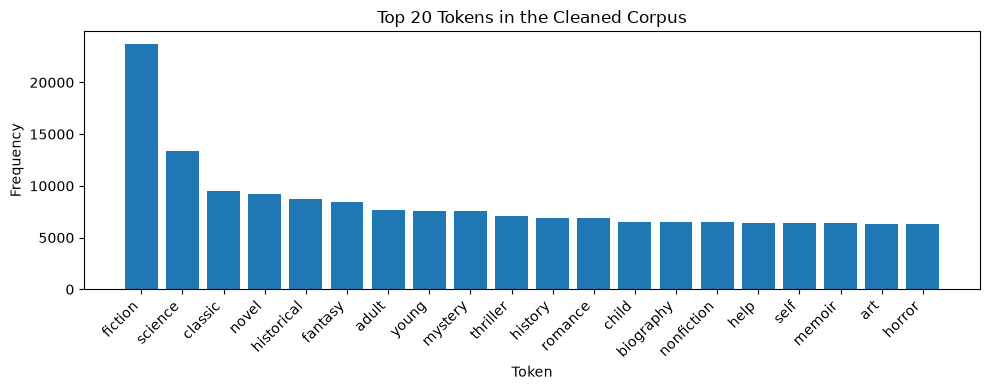

In [10]:
plt.figure(figsize=(10, 4))
top_words = token_counts.most_common(20)
plt.bar([word for word, count in top_words], [count for word, count in top_words])
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Tokens in the Cleaned Corpus")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 5. Embedding Visualization Helper

Word embeddings usually have many dimensions, such as 40 or 100. Since we cannot directly plot 40-dimensional or 100-dimensional vectors, we reduce them to 2 dimensions.

This notebook uses **PCA** when available. It is a simple SVD-based reduction.

In [11]:
def reduce_to_2d(matrix):

    matrix = np.asarray(matrix, dtype=np.float64)

    if matrix.ndim != 2:
        raise ValueError("Input matrix must be a 2D array.")

    if matrix.shape[0] < 2:
        raise ValueError("At least two vectors are required for PCA.")

    mean_vector = matrix.mean(axis=0)
    centered_matrix = matrix - mean_vector

    covariance_matrix = np.cov(centered_matrix, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    top_component_indices = sorted_indices[:2]
    top_components = eigenvectors[:, top_component_indices]

    reduced_matrix = centered_matrix @ top_components

    return reduced_matrix


class VectorVisualizer:


    def __init__(self, word_to_vec):
        self.word_to_vec = word_to_vec

    def visualize(self, target_words, title="2D Projection of Word Vectors"):
        vectors = []
        labels = []

        for word in target_words:
            if word in self.word_to_vec:
                vectors.append(self.word_to_vec[word])
                labels.append(word)
            else:
                print(f"Warning: '{word}' was not found in the vocabulary.")

        if len(vectors) < 2:
            print("At least two known words are needed to create a plot.")
            return

        matrix = np.array(vectors)
        reduced = reduce_to_2d(matrix)

        plt.figure(figsize=(10, 7))
        plt.scatter(reduced[:, 0], reduced[:, 1])

        for i, label in enumerate(labels):
            plt.annotate(
                label,
                (reduced[i, 0], reduced[i, 1]),
                xytext=(5, 5),
                textcoords="offset points",
            )

        plt.title(title)
        plt.xlabel("Principal Component 1")
        plt.ylabel("Principal Component 2")
        plt.grid(True)
        plt.show()


## 6. Word2Vec from Scratch

This section implements a small skip-gram Word2Vec model from scratch.

### Skip-gram idea

For each center word, we try to predict nearby context words.

Example sentence:

```text
russian novel family history love
```

With a window size of 2, the center word `family` has context words:

```text
russian novel history love
```

### Negative sampling idea

Instead of comparing the center word against every word in the vocabulary, we train on:

- one real context word,
- several randomly sampled incorrect context words.

The model learns to assign a high score to real pairs and a low score to negative pairs.

In [12]:
class SkipGramDataset:
    """
    Builds vocabulary and skip-gram training pairs.
    """

    def __init__(self, sentences, window_size=2):
        self.sentences = [sentence for sentence in sentences if len(sentence) > 1]
        self.window_size = window_size

        self.build_vocab()
        self.generate_pairs()

    def build_vocab(self):
        """
        Build mappings between words and integer IDs.

        Neural models work with numbers, so every token receives an integer index.
        """
        all_words = sorted(set(word for sentence in self.sentences for word in sentence))
        vocab = all_words
        self.word2idx = {word: idx for idx, word in enumerate(vocab)}
        self.idx2word = {idx: word for idx, word in enumerate(vocab)}
        self.vocab_size = len(vocab)

    def generate_pairs(self):
        """
        Generate center-context training pairs using the selected window size.
        """
        self.training_pairs = []

        for sentence in self.sentences:
            indexed_sentence = [self.word2idx[word] for word in sentence]

            for center_pos, center_word in enumerate(indexed_sentence):
                start = max(0, center_pos - self.window_size)
                end = min(len(indexed_sentence), center_pos + self.window_size + 1)

                for context_pos in range(start, end):
                    if context_pos == center_pos:
                        continue

                    context_word = indexed_sentence[context_pos]
                    self.training_pairs.append((center_word, context_word))

    def get_negative_samples(self, positive_idx, k=5):
        """
        Randomly sample k negative examples.

        The only rule here is that the negative sample cannot be the true context word.
        """
        negatives = []

        while len(negatives) < k:
            sample = random.randint(0, self.vocab_size - 1)
            if sample != positive_idx:
                negatives.append(sample)

        return negatives

In [13]:
class ScratchWord2Vec:
    """
    Minimal skip-gram Word2Vec model with negative sampling.

    W_in contains the vectors used when a word is the center word.
    W_out contains the vectors used when a word is the context word.
    """

    def __init__(self, vocab_size, embedding_dim=100, learning_rate=0.025):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.learning_rate = learning_rate

        # Randomly initialize both embedding matrices.
        self.W_in = np.random.uniform(-0.5 / embedding_dim, 0.5 / embedding_dim,(vocab_size, embedding_dim)).astype(np.float32)
        self.W_out = np.zeros((vocab_size, embedding_dim), dtype=np.float32)

    @staticmethod
    def sigmoid(x):
        """
        Convert a raw score into a probability-like value between 0 and 1.
        """
        return 1 / (1 + np.exp(-x))

    def train_pair(self, center_idx, target_idx, negative_indices):
        """
        Train on one positive center-target pair and several negative samples.

        Positive target:
        - desired label is 1.

        Negative targets:
        - desired label is 0.
        """
        # Copying avoids mixing old and already-updated vectors within the same step.
        center_vec = self.W_in[center_idx].copy()
        target_vec = self.W_out[target_idx].copy()

        # Positive updates
        positive_score = np.dot(center_vec, target_vec)
        positive_pred = self.sigmoid(positive_score)
        positive_error = 1.0 - positive_pred

        self.W_in[center_idx] += self.learning_rate * positive_error * target_vec
        self.W_out[target_idx] += self.learning_rate * positive_error * center_vec

        # ----- Negative updates -----
        for neg_idx in negative_indices:
            neg_vec = self.W_out[neg_idx].copy()

            negative_score = np.dot(center_vec, neg_vec)
            negative_pred = self.sigmoid(negative_score)
            negative_error = 0.0 - negative_pred

            self.W_in[center_idx] += self.learning_rate * negative_error * neg_vec
            self.W_out[neg_idx] += self.learning_rate * negative_error * center_vec

    def get_vector(self, idx):
        """
        Return the learned input vector for a word index.
        """
        return self.W_in[idx]

    def save(self, path, word2idx, idx2word):
        """
        Save the model weights and vocabulary mappings.
        """
        data = {
            "W_in": self.W_in,
            "W_out": self.W_out,
            "vocab_size": self.vocab_size,
            "embedding_dim": self.embedding_dim,
            "word2idx": word2idx,
            "idx2word": idx2word,
        }

        with open(path, "wb") as f:
            pickle.dump(data, f)

    @classmethod
    def load(cls, path):
        """
        Load a saved scratch Word2Vec model.
        """
        with open(path, "rb") as f:
            data = pickle.load(f)

        vocab_size = data["vocab_size"]
        embedding_dim = data["embedding_dim"]

        model = cls(vocab_size=vocab_size, embedding_dim=embedding_dim)
        model.W_in = data["W_in"]
        model.W_out = data["W_out"]
        model.word2idx = data["word2idx"]
        model.idx2word = data["idx2word"]

        return model

In [14]:
class Trainer:
    """
    Training loop for the scratch Word2Vec model.
    """

    def __init__(self, model, dataset, epochs=5, negative_samples=5, max_pairs=None):
        self.model = model
        self.dataset = dataset
        self.epochs = epochs
        self.negative_samples = negative_samples
        self.max_pairs = max_pairs

    def train(self):
        pairs = self.dataset.training_pairs

        # For large datasets, max_pairs can be used to keep demonstration runtime reasonable.
        # For the built-in dataset, all pairs are used.
        if self.max_pairs is not None and self.max_pairs < len(pairs):
            pairs = random.sample(pairs, self.max_pairs)
        for epoch in range(self.epochs):
            print(f"Epoch {epoch + 1}/{self.epochs}")

            for center_idx, target_idx in tqdm(pairs, leave=False):
                negative_indices = self.dataset.get_negative_samples(
                    positive_idx=target_idx,
                    k=self.negative_samples,
                )

                self.model.train_pair(
                    center_idx=center_idx,
                    target_idx=target_idx,
                    negative_indices=negative_indices,
                )

### Train the scratch Word2Vec model

The training settings below are intentionally small enough to run quickly in a notebook.

In [15]:
scratch_dataset = SkipGramDataset(
    sentences=tokenized_sentences,
    window_size=3,
)

scratch_model = ScratchWord2Vec(
    vocab_size=scratch_dataset.vocab_size,
    embedding_dim=100,
    learning_rate=0.01,
)

scratch_trainer = Trainer(
    model=scratch_model,
    dataset=scratch_dataset,
    epochs=5,
    negative_samples=5,
    max_pairs=None,
)

print(f"Vocabulary size: {scratch_dataset.vocab_size}")
print(f"Number of skip-gram pairs: {len(scratch_dataset.training_pairs)}")

scratch_trainer.train()
print("Scratch Word2Vec training complete.")

Vocabulary size: 22476
Number of skip-gram pairs: 3486852
Epoch 1/5


  0%|          | 0/3486852 [00:00<?, ?it/s]

Epoch 2/5


  0%|          | 0/3486852 [00:00<?, ?it/s]

Epoch 3/5


...

Epoch 4/5


  0%|          | 0/3486852 [00:00<?, ?it/s]

Epoch 5/5


  0%|          | 0/3486852 [00:00<?, ?it/s]

Scratch Word2Vec training complete.


## 7. Testing Semantic Consistency with Odd-One-Out Questions

After training word embeddings, we need a simple way to inspect whether the model has learned meaningful relationships between words.


In each question, the model receives a small group of words. Most of the words should belong to the same semantic category, while one word should be less related to the others.

For example:

```text
fiction, novel, story, business

In [ ]:
class ScratchModelTester:
    """
    Tests scratch Word2Vec embeddings.

    This class supports:
    1. nearest-neighbor search,
    2. odd-one-out semantic testing,
    3. exporting word vectors for visualization.
    """

    def __init__(self, model, word2idx, idx2word):
        self.model = model
        self.word2idx = word2idx
        self.idx2word = idx2word

        # Store all learned word vectors in a dictionary.
        self.word_to_vec = {
            None # TODO
        }

    def _to_numpy(self, vector):
        """
        Convert a vector to a NumPy array.

        This keeps the code safe whether the model returns
        a NumPy array or a PyTorch tensor.
        """
        if hasattr(vector, "detach"):
            vector = vector.detach().cpu().numpy()

        pass # TODO

    def get_vector(self, word):
        """
        Return the vector for a word.
        """
        if word not in self.word_to_vec:
            return None

        pass # TODO

    def cosine_similarity(self, vector_a, vector_b):
        """
        Compute cosine similarity between two vectors.

        Cosine similarity measures whether two vectors point in a similar
        direction, which is usually more useful for word embeddings than
        raw Euclidean distance.
        """
        norm_a = None # TODO
        norm_b = None # TODO

        if norm_a == 0 or norm_b == 0:
            return 0.0

        pass # TODO

    def find_similar_words(self, word, top_n=10):
        """
        Find the words that are most similar to the input word.
        """
        target_vector = None # TODO

        if target_vector is None:
            return f"'{word}' was not found in the vocabulary."

        similarities = []

        for other_word, other_vector in self.word_to_vec.items():
            if other_word == word:
                continue

            similarity = None # TODO
            similarities.append((other_word, similarity))

        similarities.sort(key=lambda item: item[1], reverse=True)

        pass # TODO

    def odd_one_out(self, words):
        """
        Find the word that does not belong in a group.

        Method:
        - For each word, calculate its average cosine similarity to all
          other words in the group.
        - The word with the lowest average similarity is selected as the
          odd one out.
        """
        vectors = {}

        # First, make sure every word exists in the vocabulary.
        for word in words:
            vector = self.get_vector(word)

            if vector is None:
                return {
                    "prediction": None,
                    "error": f"'{word}' was not found in the vocabulary.",
                    "scores": None,
                }

            vectors[word] = vector

        scores = {}

        # Calculate how related each word is to the rest of the group.
        for word in words:
            similarities = []

            for other_word in words:
                if word == other_word:
                    continue

                similarity = None # TODO
                similarities.append(similarity)

            scores[word] = np.mean(similarities)

        # The word with the lowest average similarity is the odd one out.
        prediction = None # TODO

        pass # TODO

    def get_vector_dict(self):
        """
        Return a dictionary mapping each word to its vector.

        This is useful for visualization.
        """
        return self.word_to_vec

In [ ]:
odd_one_out_questions = [
    #Easy tests
    (["england", "london", "british", "dostoevsky"], "dostoevsky"),
    (["harry", "potter", "hogwarts", "tolstoy"], "tolstoy"),
    (["jane", "austen", "darcy", "wizard"], "wizard"),
    (["russia", "russian", "dostoevsky", "romance"], "romance"),
    (["america", "american", "united", "hogwarts"], "hogwarts"),
    (["france", "paris", "european", "vampire"], "vampire"),
    (["king", "queen", "lord", "british"], "british"),
    (["school", "student", "teacher", "tolstoy"], "tolstoy"),
    (["science", "fiction", "fantasy", "london"], "london"),
    (["mystery", "thriller", "crime", "austen"], "austen"),
    #Harder tests
    (["fiction", "novel", "story", "business"], "business"),
    (["fantasy", "magic", "fiction", "biography"], "biography"),
    (["mystery", "thriller", "crime", "poetry"], "poetry"),
    (["history", "historical", "century", "romance"], "romance"),
    (["biography", "memoir", "life", "horror"], "horror"),
    (["child", "young", "adult", "business"], "business"),
    (["austen", "fitzgerald", "miller", "travel"], "travel"),
    (["romance", "love", "family", "science"], "science"),
    (["music", "art", "poetry", "thriller"], "thriller"),
    (["business", "psychology", "self", "fantasy"], "fantasy"),
]


In [ ]:
scratch_tester = ScratchModelTester(
    model=scratch_model,
    word2idx=scratch_dataset.word2idx,
    idx2word=scratch_dataset.idx2word,
)

correct = 0
total = 0

for words, expected in odd_one_out_questions:
    result = None # TODO

    print(f"Words: {words}")
    print(f"Expected odd word: {expected}")

    if result["error"] is not None:
        print(f"Model output: {result['error']}")
    else:
        prediction = None # TODO
        is_correct = None # TODO

        correct += None # TODO
        total += 1

        print(f"Model output: {prediction}")
        print(f"Correct: {is_correct}")

        print("Scores, lower means more likely to be odd:")
        for word, score in sorted(result["scores"].items(), key=lambda item: item[1]):
            print(f"  {word:12s} {score:.4f}")

    print("-" * 60)

print(f"Final score: {correct}/{total}")

## Model Performance Note

The scratch Word2Vec model has learned from the training corpus, but its results are still limited. This is expected because the dataset is relatively small and the model is trained from scratch without the optimizations used in larger embedding libraries.

Some predictions may be reasonable, while others may look noisy or unrelated. This does not mean the implementation is wrong; it shows that word embeddings need enough clean text and repeated context patterns to learn strong semantic relationships.

To improve the results, you can experiment with:

- increasing the number of training epochs,
- using a larger embedding dimension,
- cleaning the corpus more carefully,
- training on a larger dataset.

## 8. Visualizing Scratch Word2Vec Vectors

The plot below projects selected word vectors into 2D.

Words that appear near each other have vectors that are relatively similar under the learned embedding space.

In [ ]:
words_to_visualize = [
    "russian",
    "russia",
    "egypt",
    "africa",
    "america",
    "author",
    "friedrich",
    "albert",
    "rowl",
    "nietzsch",
    "camu",
    "jane",
    "austen",
]

In [ ]:
scratch_visualizer = VectorVisualizer(scratch_tester.get_vector_dict())
scratch_visualizer.visualize(
    target_words=words_to_visualize,
    title="Scratch Word2Vec: 2D Word Vector Projection",
)

## 9. FastText with Gensim

FastText improves on basic Word2Vec by using **subword information**.

Instead of learning only a vector for each whole word, FastText also learns from character n-grams. This helps the model handle:

- rare words,
- misspellings,
- related word forms,
- words that share roots.

This section trains a FastText model using Gensim.

In [ ]:
try:
    from gensim.models import FastText as GensimFastText

    GENSIM_AVAILABLE = True
except Exception as e:
    GensimFastText = None
    GENSIM_AVAILABLE = False
    print("Gensim is not available in this environment.")
    print("Error:", e)

print(f"Gensim available: {GENSIM_AVAILABLE}")

In [ ]:
from time import perf_counter
from tqdm.auto import tqdm
from gensim.models.callbacks import CallbackAny2Vec

class TqdmEpochCallback(CallbackAny2Vec):
    """
    Show a tqdm progress bar during Gensim training.
    """

    def __init__(self, total_epochs):
        self.progress_bar = tqdm(
            total=total_epochs,
            desc="Training Gensim FastText",
        )

    def on_epoch_end(self, model):
        self.progress_bar.update(1)

    def on_train_end(self, model):
        self.progress_bar.close()


gensim_fasttext_model = None

if GENSIM_AVAILABLE:
    GENSIM_VECTOR_SIZE = 40
    GENSIM_WINDOW_SIZE = 10
    GENSIM_MIN_COUNT = 1
    GENSIM_WORKERS = 1
    GENSIM_EPOCHS = 100

    gensim_fasttext_model = GensimFastText(
        vector_size=GENSIM_VECTOR_SIZE,
        window=GENSIM_WINDOW_SIZE,
        min_count=GENSIM_MIN_COUNT,
        workers=GENSIM_WORKERS,
        seed=RANDOM_SEED,
    )

    gensim_fasttext_model.build_vocab(corpus_iterable=tokenized_sentences)

    print("Starting Gensim FastText training...")
    print(f"Vocabulary size: {len(gensim_fasttext_model.wv.index_to_key)}")
    print(f"Epochs: {GENSIM_EPOCHS}")

    start_time = perf_counter()

    gensim_fasttext_model.train(
        corpus_iterable=tokenized_sentences,
        total_examples=gensim_fasttext_model.corpus_count,
        epochs=GENSIM_EPOCHS,
        callbacks=[TqdmEpochCallback(GENSIM_EPOCHS)],
    )

    elapsed_time = None # TODO

    print("Gensim FastText training complete.")
    print(f"Training time: {elapsed_time:.2f} seconds")

else:
    print("Skipping Gensim FastText training because Gensim is unavailable.")

In [ ]:
class GensimFastTextTester:
    """
    Tests a trained Gensim FastText model using nearest-neighbor search
    and odd-one-out semantic evaluation.
    """

    def __init__(self, model):
        self.model = model

        self.word_to_vec = {
            word: np.asarray(self.model.wv[word], dtype=np.float64)
            for word in self.model.wv.index_to_key
        }

    def get_vector(self, word):
        """
        Return the vector for a word.

        Gensim FastText can sometimes create vectors for words that were not
        directly seen during training because it uses subword information.
        """
        try:
            return np.asarray(self.model.wv[word], dtype=np.float64)
        except KeyError:
            return None

    def cosine_similarity(self, vector_a, vector_b):
        """
        Compute cosine similarity between two vectors.
        """
        norm_a = None # TODO
        norm_b = None # TODO

        if norm_a == 0 or norm_b == 0:
            return 0.0

        pass # TODO

    def find_similar_words(self, word, top_n=10):
        """
        Find words that are most similar to the input word.
        """
        try:
            return self.model.wv.most_similar(word, topn=top_n)
        except KeyError:
            return f"'{word}' was not found in the vocabulary."

    def odd_one_out(self, words):
        """
        Find the word that does not belong in a group.

        For each word, we calculate its average cosine similarity to the other
        words in the group. The word with the lowest average similarity is
        selected as the odd one out.
        """
        vectors = {}

        for word in words:
            vector = self.get_vector(word)

            if vector is None:
                return {
                    "prediction": None,
                    "error": f"'{word}' was not found in the vocabulary.",
                    "scores": None,
                }

            vectors[word] = vector

        scores = {}

        for word in words:
            similarities = []

            for other_word in words:
                if word == other_word:
                    continue

                similarity = None # TODO
                similarities.append(similarity)

            scores[word] = np.mean(similarities)

        prediction = None # TODO

        pass # TODO

    def get_vector_dict(self):
        """
        Return word vectors for visualization.
        """
        return self.word_to_vec

In [ ]:
if gensim_fasttext_model is not None:
    gensim_tester = GensimFastTextTester(gensim_fasttext_model)

    correct = 0
    total = 0

    for words, expected in odd_one_out_questions:
        result = gensim_tester.odd_one_out(words)

        print(f"Words: {words}")
        print(f"Expected odd word: {expected}")

        if result["error"] is not None:
            print(f"Model output: {result['error']}")
        else:
            prediction = None # TODO
            is_correct = None # TODO

            correct += None # TODO
            total += 1

            print(f"Model output: {prediction}")
            print(f"Correct: {is_correct}")

            print("Scores, lower means more likely to be odd:")
            for word, score in sorted(result["scores"].items(), key=lambda item: item[1]):
                print(f"  {word:12s} {score:.4f}")

        print("-" * 60)

    print(f"Final score: {correct}/{total}")

    gensim_visualizer = VectorVisualizer(gensim_tester.get_vector_dict())
    gensim_visualizer.visualize(
        target_words=words_to_visualize,
        title="Gensim FastText: 2D Word Vector Projection",
    )

else:
    print("No Gensim FastText model is available to test.")

## 10. FastText with the Native `fasttext` Package

The native FastText implementation expects text input as lines of tokens.

Since this notebook already has cleaned lines in memory, we create a temporary text corpus during this cell and use it for training.

This section is optional because the `fasttext` package can require compilation on some systems.

In [ ]:
try:
    import fasttext

    NATIVE_FASTTEXT_AVAILABLE = True
except Exception as e:
    fasttext = None
    NATIVE_FASTTEXT_AVAILABLE = False
    print("The native fasttext package is not available in this environment.")
    print("Error:", e)

print(f"Native fasttext available: {NATIVE_FASTTEXT_AVAILABLE}")

In [ ]:
from threading import Thread, Event
from time import perf_counter, sleep
import os
native_fasttext_model = None

if NATIVE_FASTTEXT_AVAILABLE:
    NATIVE_VECTOR_SIZE = 40
    NATIVE_WINDOW_SIZE = 10
    NATIVE_EPOCHS = 25
    NATIVE_MIN_COUNT = 1

    with tempfile.NamedTemporaryFile(
        mode="w",
        encoding="utf-8",
        suffix=".txt",
        delete=False,
    ) as tmp:
        tmp.write("\n".join(cleaned_lines))
        temp_corpus_path = tmp.name

    stop_progress = Event()

    def show_training_progress():
        """
        Native fastText does not provide Python callbacks for each epoch.
        This progress bar shows that training is still running and displays
        elapsed time while the native training function is active.
        """
        with tqdm(desc="Training Native FastText", unit="sec") as progress_bar:
            while not stop_progress.is_set():
                sleep(1)
                progress_bar.update(1)

    progress_thread = None # TODO
    progress_thread.start()

    print("Starting native FastText training...")
    print(f"Vector size: {NATIVE_VECTOR_SIZE}")
    print(f"Window size: {NATIVE_WINDOW_SIZE}")
    print(f"Epochs: {NATIVE_EPOCHS}")
    print(f"Minimum word count: {NATIVE_MIN_COUNT}")

    start_time = None # TODO

    try:
        native_fasttext_model = fasttext.train_unsupervised(
            input=temp_corpus_path,
            model="skipgram",
            dim=NATIVE_VECTOR_SIZE,
            ws=NATIVE_WINDOW_SIZE,
            epoch=NATIVE_EPOCHS,
            minCount=NATIVE_MIN_COUNT,
            verbose=0,
        )
    finally:
        stop_progress.set()
        progress_thread.join()

        if os.path.exists(temp_corpus_path):
            os.remove(temp_corpus_path)

    elapsed_time = None # TODO

    print("Native FastText training complete.")
    print(f"Training time: {elapsed_time:.2f} seconds")
    print(f"Vocabulary size: {len(native_fasttext_model.get_words())}")

else:
    print("Skipping native FastText training because the package is unavailable.")

In [ ]:
class NativeFastTextTester:
    """
    Tests a model trained with the native fasttext package using
    nearest-neighbor search and odd-one-out semantic evaluation.
    """

    def __init__(self, model):
        self.model = model
        self.words = self.model.get_words()

        self.word_to_vec = {
            word: np.asarray(self.model.get_word_vector(word), dtype=np.float64)
            for word in self.words
        }

    def get_vector(self, word):
        """
        Return the vector for a word.

        Native FastText can generate vectors for unseen words using subword
        information, but for evaluation we only accept words that are part of
        the learned vocabulary.
        """
        if word not in self.word_to_vec:
            return None

        pass # TODO

    def cosine_similarity(self, vector_a, vector_b):
        """
        Compute cosine similarity between two vectors.
        """
        norm_a = None # TODO
        norm_b = None # TODO

        if norm_a == 0 or norm_b == 0:
            return 0.0

        pass # TODO

    def find_similar_words(self, word, top_n=10):
        """
        Find the words that are most similar to the input word.
        """
        target_vector = None # TODO

        if target_vector is None:
            return f"'{word}' was not found in the vocabulary."

        similarities = []

        for other_word, other_vector in self.word_to_vec.items():
            if other_word == word:
                continue

            similarity = None # TODO
            similarities.append((other_word, similarity))

        similarities.sort(key=lambda item: item[1], reverse=True)

        return similarities[:top_n]

    def odd_one_out(self, words):
        """
        Find the word that does not belong in a group.

        For each word, we calculate its average cosine similarity to the other
        words in the group. The word with the lowest average similarity is
        selected as the odd one out.
        """
        vectors = {}

        for word in words:
            vector = self.get_vector(word)

            if vector is None:
                return {
                    "prediction": None,
                    "error": f"'{word}' was not found in the vocabulary.",
                    "scores": None,
                }

            vectors[word] = vector

        scores = {}

        for word in words:
            similarities = []

            for other_word in words:
                if word == other_word:
                    continue

                similarity = None # TODO
                similarities.append(similarity)

            scores[word] = np.mean(similarities)

        prediction = None # TODO

        pass # TODO

    def get_vector_dict(self):
        """
        Return word vectors for visualization.
        """
        return self.word_to_vec

In [ ]:
if native_fasttext_model is not None:
    native_tester = NativeFastTextTester(native_fasttext_model)

    correct = 0
    total = 0

    for words, expected in odd_one_out_questions:
        result = None # TODO

        print(f"Words: {words}")
        print(f"Expected odd word: {expected}")

        if result["error"] is not None:
            print(f"Model output: {result['error']}")
        else:
            prediction = None # TODO
            is_correct = None # TODO

            correct += None # TODO
            total += 1

            print(f"Model output: {prediction}")
            print(f"Correct: {is_correct}")

            print("Scores, lower means more likely to be odd:")
            for word, score in sorted(result["scores"].items(), key=lambda item: item[1]):
                print(f"  {word:12s} {score:.4f}")

        print("-" * 60)

    print(f"Final score: {correct}/{total}")

    native_visualizer = VectorVisualizer(native_tester.get_vector_dict())
    native_visualizer.visualize(
        target_words=words_to_visualize,
        title="Native FastText: 2D Word Vector Projection",
    )

else:
    print("No native FastText model is available to test.")

## 11. Optional: Save and Reload the Scratch Model

Saving a trained model is useful when training takes a long time and we want to reuse the model later.

This section demonstrates saving and reloading the scratch Word2Vec model.

In [ ]:
scratch_model_path = Path("scratch_word2vec_answer.model")

scratch_model.save(
    path=scratch_model_path,
    word2idx=scratch_dataset.word2idx,
    idx2word=scratch_dataset.idx2word,
)

reloaded_scratch_model = ScratchWord2Vec.load(scratch_model_path)

print(f"Scratch model saved and reloaded from: {scratch_model_path}")
print(f"Reloaded embedding shape: {reloaded_scratch_model.W_in.shape}")

## 12. Model Comparison

explain each model and compare their results


##TODO